In [2]:
import numpy as np
import math
import pandas as pd
import cv2
import os
import re
import tqdm
from scipy.io import loadmat
from pdf2image import convert_from_path

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

from PIL import Image
import pytesseract

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras import backend as K

#from utils import *

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from keras.callbacks import ModelCheckpoint
from keras.optimizers import Adam, SGD
from keras.layers import *

from keras.applications import MobileNetV2
from keras.applications import InceptionResNetV2

from keras.models import Model
from keras.models import model_from_json

from keras.models import load_model

In [3]:
## Find out all individual boxes for subsequent text extraction :

def all_boxes(pred_bom_id):
    
    boxes_list = []
    pred_bom = cv2.imread(pred_bom_id)
    pred_bom_gray = cv2.cvtColor(pred_bom, cv2.COLOR_BGR2GRAY)

    ##thresholding the image to a binary image
    thresh,img_bin = cv2.threshold(pred_bom_gray,0,255,cv2.THRESH_BINARY | cv2.THRESH_OTSU)

    #inverting the image 
    img_bin_invert = 255-img_bin

    img_pil = Image.fromarray(img_bin_invert)
        
    display(img_pil) 
      
    # Length(width) of kernel as 100th of total width
    kernel_len = pred_bom_gray.shape[1]//100

    # Defining a vertical kernel to detect all vertical lines of image 
    ver_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, kernel_len))

    # Defining a horizontal kernel to detect all horizontal lines of image
    hor_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_len, 1))

    #Use vertical kernel to detect and save the vertical lines in a jpg
    image_1 = cv2.erode(img_bin_invert, ver_kernel, iterations=3)
    vertical_lines = cv2.dilate(image_1, ver_kernel, iterations=3)

    #Use horizontal kernel to detect and save the horizontal lines in a jpg
    image_2 = cv2.erode(img_bin_invert, hor_kernel, iterations=3)
    horizontal_lines = cv2.dilate(image_2, hor_kernel, iterations=3)

    # Combine horizontal and vertical lines in a new third image, with both having same weight.
    img_vh = cv2.addWeighted(vertical_lines, 0.5, horizontal_lines, 0.5, 0.0)

    # A kernel of 2x2
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    # print('Final kernel = ', kernel)

    img_vh_d = cv2.dilate(img_vh, kernel, iterations=2)

    img_vh_d_pil = Image.fromarray(img_vh_d)
        
    # display(img_vh_d_pil)
        
    # Defining the cell boxes

    contours, hierarchy = cv2.findContours(img_vh_d, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    boxes = np.zeros((len(contours), 4))

    for i in range(len(contours)):
    
        cnt = contours[i]
        x, y, w, h = cv2.boundingRect(cnt)
        boxes[i, 0] = x
        boxes[i, 1] = y
        boxes[i, 2] = w
        boxes[i, 3] = h

    # print(len(boxes))
        
    boxes_list.append(boxes)
    
    return boxes_list      ## ## in format x, y, w, h


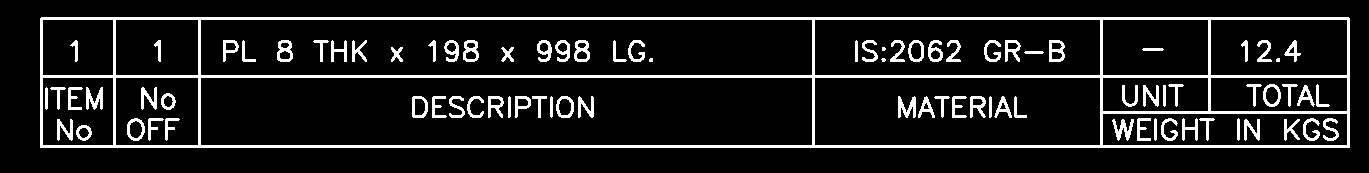

In [23]:
pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom/1039.jpg"
bom_boxes = all_boxes(pred_bom_id)

In [24]:
print(type(bom_boxes))
print(len(bom_boxes))
print(bom_boxes)

<class 'list'>
1
[array([[  40.,   17., 1312.,  133.],
       [1104.,  115.,  244.,   31.],
       [1212.,   79.,  136.,   33.],
       [1104.,   79.,  105.,   33.],
       [ 816.,   79.,  285.,   67.],
       [ 202.,   79.,  611.,   67.],
       [ 117.,   79.,   82.,   67.],
       [  44.,   79.,   70.,   67.],
       [1212.,   21.,  136.,   55.],
       [1104.,   21.,  105.,   55.],
       [ 816.,   21.,  285.,   55.],
       [ 202.,   21.,  611.,   55.],
       [ 117.,   21.,   82.,   55.],
       [  44.,   21.,   70.,   55.]])]


In [5]:
print(type(bom_boxes[0]))
print(bom_boxes[0].shape)

<class 'numpy.ndarray'>
(135, 4)


In [7]:
## Take out header boxe and all other box info for all items separately :

def header_and_item(pred_bom_id):
    
    bom_boxes = all_boxes(pred_bom_id)

    for i in range(len(bom_boxes)):

        if i == 0:
            col_count_list = []
            header_boxes_list = []
            bom_boxes_list = []
            item_index_width_list = []

        boxes_1 = bom_boxes[i][1:]   ## removing the line of full box i.e. removing 0th row
        
        ## Find number of columns i.e. max occurance of any y value :

        y_list = boxes_1[:, 1].tolist()   ## since boxes are in x,y,w,h format (output from cv2.boundingRect)

        col_count_array = np.bincount(y_list)  ## no. of occurances of each y-value
        col_count = col_count_array.max()  ## max. no. of occurances of any one y-value

        print('No. of columns = ', col_count)
        

        # Now fid the Header row.

        # In drawings, header row is always at the bottom.
        # Output of cv2.boundingRect always starts with the box of complete BOM
        # After this 1st row, the output starts with the bottom_most_right_most (in this order) box details.

        # So, y value of boxes[1] is the bottom_most-right_most (in this order) cell y value.

        y_bmrm_cell = boxes_1[0][1]  # y value of 1st bottom most cell

        # If occurances of this y value of 1st bottom most cell = number of columns, then this is the y value of Header Row

        num_col = y_list.count(y_bmrm_cell)   ## no. of occurances of y_bmrm_cell value 

        if num_col == col_count:
    
            y_header_row = y_bmrm_cell
            item_index_width = boxes_1[col_count-1, 2]  # This is the width of the 1st column i.e. 'Item No.' column
            bom_boxes_1 = boxes_1[1:]   ## remove 1st header row for bom consideration
    
        else:
        
            y_next_cell = boxes_1[1][1]

            num_col = y_list.count(y_next_cell)

            if num_col == col_count:
    
                y_header_row = y_next_cell
                item_index_width = boxes_1[col_count, 2]
                bom_boxes_1 = boxes_1[2:]    ## remove 1st 2 rows for bom consideration

        header_boxes = boxes_1[boxes_1[:, 1] == y_header_row]
    
        bom_boxes = bom_boxes_1[bom_boxes_1[:, 1] != y_header_row]
        
        col_count_list.append(col_count)
        item_index_width_list.append(item_index_width)
        header_boxes_list.append(header_boxes)
        bom_boxes_list.append(bom_boxes)
    
    return col_count_list, item_index_width_list , header_boxes_list, bom_boxes_list  ## all boxes in x, y, w, h format


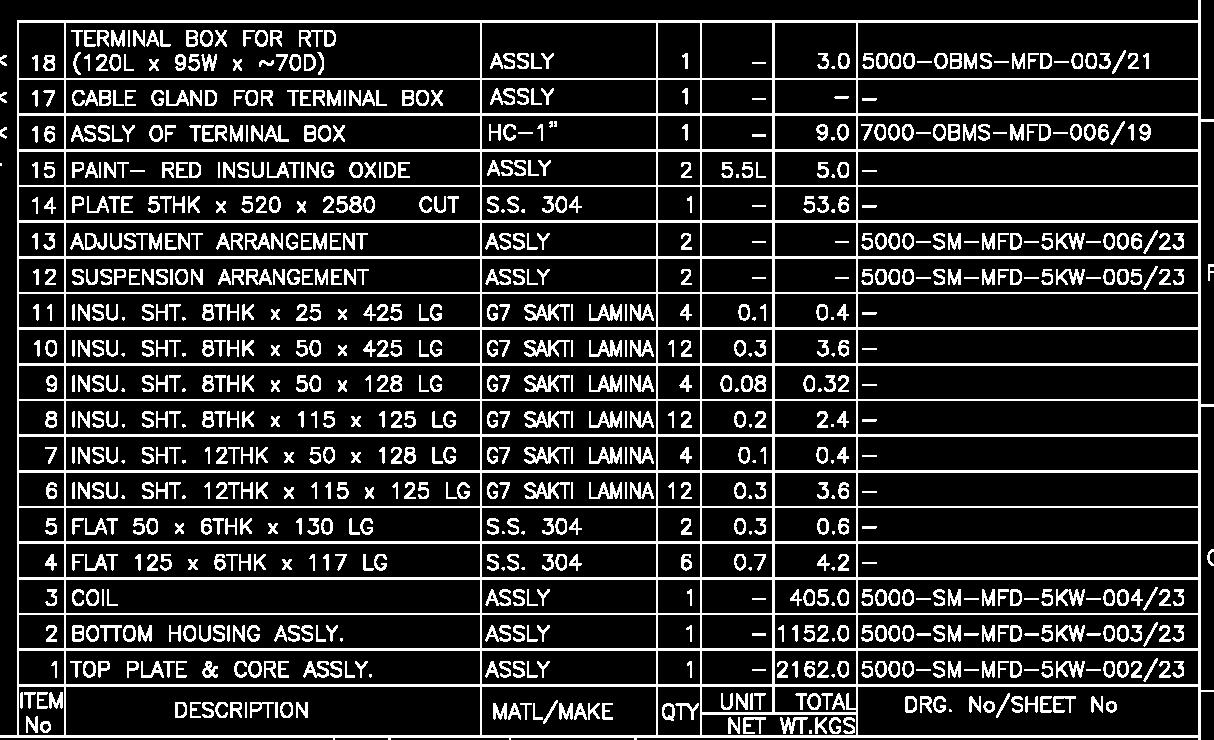

No. of columns =  7


In [7]:
col_count_list, item_index_width_list , header_boxes_list, bom_boxes_list =  header_and_item(pred_bom_id) ## all boxes in x, y, w, h format


In [8]:
print(col_count_list)
print('============================================')
print(item_index_width_list)
print('============================================')
print(header_boxes_list)
print('============================================')
print(bom_boxes_list)

[7]
[45.0]
[array([[859., 688., 340.,  48.],
       [776., 688.,  81.,  25.],
       [703., 688.,  70.,  25.],
       [659., 688.,  42.,  48.],
       [483., 688., 174.,  48.],
       [ 67., 688., 414.,  48.],
       [ 20., 688.,  45.,  48.]])]
[array([[859., 652., 340.,  33.],
       [776., 652.,  81.,  33.],
       [703., 652.,  70.,  33.],
       [659., 652.,  42.,  33.],
       [483., 652., 174.,  33.],
       [ 67., 652., 414.,  33.],
       [ 20., 652.,  45.,  33.],
       [859., 616., 340.,  33.],
       [776., 616.,  81.,  33.],
       [703., 616.,  70.,  33.],
       [659., 616.,  42.,  33.],
       [483., 616., 174.,  33.],
       [ 67., 616., 414.,  33.],
       [ 20., 616.,  45.,  33.],
       [859., 581., 340.,  33.],
       [776., 581.,  81.,  33.],
       [703., 581.,  70.,  33.],
       [659., 581.,  42.,  33.],
       [483., 581., 174.,  33.],
       [ 67., 581., 414.,  33.],
       [ 20., 581.,  45.,  33.],
       [859., 545., 340.,  33.],
       [776., 545.,  81.,  3

In [8]:
## Making the dataframe of BOM :

def bom_df_rev(pred_bom_id):
    
    col_count_list, item_index_width_list, header_boxes_list, bom_boxes_list =  header_and_item(pred_bom_id)
    pred_bom = cv2.imread(pred_bom_id)
    pred_bom_clr = cv2.cvtColor(pred_bom, cv2.COLOR_BGR2GRAY)
    
    ## First find the header info - only one header box will be considered out of list :
    ## It is expected that all header info in one drawing should be same :
    
    
#    print(type(col_count_list), '====', col_count_list)
#    print(type(item_index_width_list), '====', item_index_width_list)
    
#    print('item index width = ', item_index_width_list)

    width_list = header_boxes_list[0][:,2]   # to find width of columns
    x_list = header_boxes_list[0][:, 0]
    
    width_frequency = np.unique(width_list, return_counts=True)[1] # to check how many columns of same width
    
    
    
    print('width_frequency = ', width_frequency)
    
    print('width list = ', width_list)

    
    # Make a list of widths of all columns 
    
    all_width_list = bom_boxes_list[0][:,2].tolist() ## serialised from right to left
    row_count_array = np.bincount(all_width_list)  ## no. of occurances of each width-value
    row_count_apparent = row_count_array.max()
    
    row_count = row_count_apparent // np.max(width_frequency)
    
    print('Row count = ', row_count)
    
    
    aa = header_boxes_list[0].tolist()
    
    
    header_text = []
    kount = 0

    for i in range(len(aa)):
    
        yy_gray = pred_bom[0][int(aa[i][1]-1):int(aa[i][1] + aa[i][3] - 1), int(aa[i][0]-1):int(aa[i][0] + aa[i][2] - 1)]
    
        thresh, yy_gray_1 = cv2.threshold(yy_gray, 0,255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
    
        text = pytesseract.image_to_string(yy_gray_1, config='--psm 6 --oem 2')

        
        header_text.append(text)
        
    header_text.append('img_id')
    serialised_header_text = header_text[::-1]
    
#    print(serialised_header_text)
    
    ## Now find all item or BOM info :=======================================================================
    
    num_item = 0
    bom_text = []
    item_count = 0
    
    for i in range(len(bom_boxes_list)):
        
#        print('bom_boxes_list = ', len(bom_boxes_list))
        
#        print(bom_boxes_list[i])
        
        item_count = item_count + np.count_nonzero(bom_boxes_list[i][:, 2] == item_index_width_list[i])
        
        if width_frequency[0] > 1:        # this shows more cols of same width as index col.
            
            item_count = item_count // width_frequency[0]
            
        print('No. of Items = ', item_count)
            
        y_unique = np.unique(bom_boxes_list[i][:,1])  # serialised from top to bottom
        y_unique = y_unique[::-1]        ## serialised from bottom to top
        
#        print(y_unique)

#        num_item = num_item + len(y_unique)

        for j in y_unique:
    
            bom_sub_text = []
            aa = np.ones((col_count_list[0], 4))
        
            # bb = bom_boxes_list[i]
    
            bb = bom_boxes_list[i][bom_boxes_list[i][:, 1] == j]
        
#            print(bb)
#            print('==================================================')
            
            for k in range(len(width_list)):
                for l in range(len(bb)):
                    if (bb[l][2]+bb[l][0]) == (width_list[k]+x_list[k]):
                        aa[k, :] = bb[l, :]
                        
#            print(aa)
#            print('=======================================================')
#            print('=======================================================')

            
            for k in range(len(aa)):
    
#        thresh, xx_gray_1 = cv2.threshold(xx_gray,0,255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
    
                yy_gray = pred_bom[i][int(aa[k][1]-1):int(aa[k][1] + aa[k][3] - 1), int(aa[k][0]-1):int(aa[k][0] + aa[k][2] - 1)]
        
                text = pytesseract.image_to_string(yy_gray, config=' --psm 6 --oem 3')
            
#                print('text type = ', type(text), 'text value = ', text)
        
                bom_sub_text.append(text)
            
                kount = kount + 1
                
                if kount == col_count_list[0]:
                    bom_sub_text.append(img_id)
                    kount = 0
                
                
    
            bom_sub_text_rev = bom_sub_text[::-1]
        
            
#            print('length of sub_text = ', len(bom_sub_text_rev))
            bom_text.append(bom_sub_text_rev)
            
        
            
        #Creating a dataframe of the generated OCR list
    arr = np.array(bom_text)
    
    arr_reshape = arr.reshape(row_count, col_count_list[0]+1)
             
#    dataframe = pd.DataFrame(arr.reshape(row_count, col_count_list[0]), columns = serialised_header_text)
    
    return arr_reshape, serialised_header_text


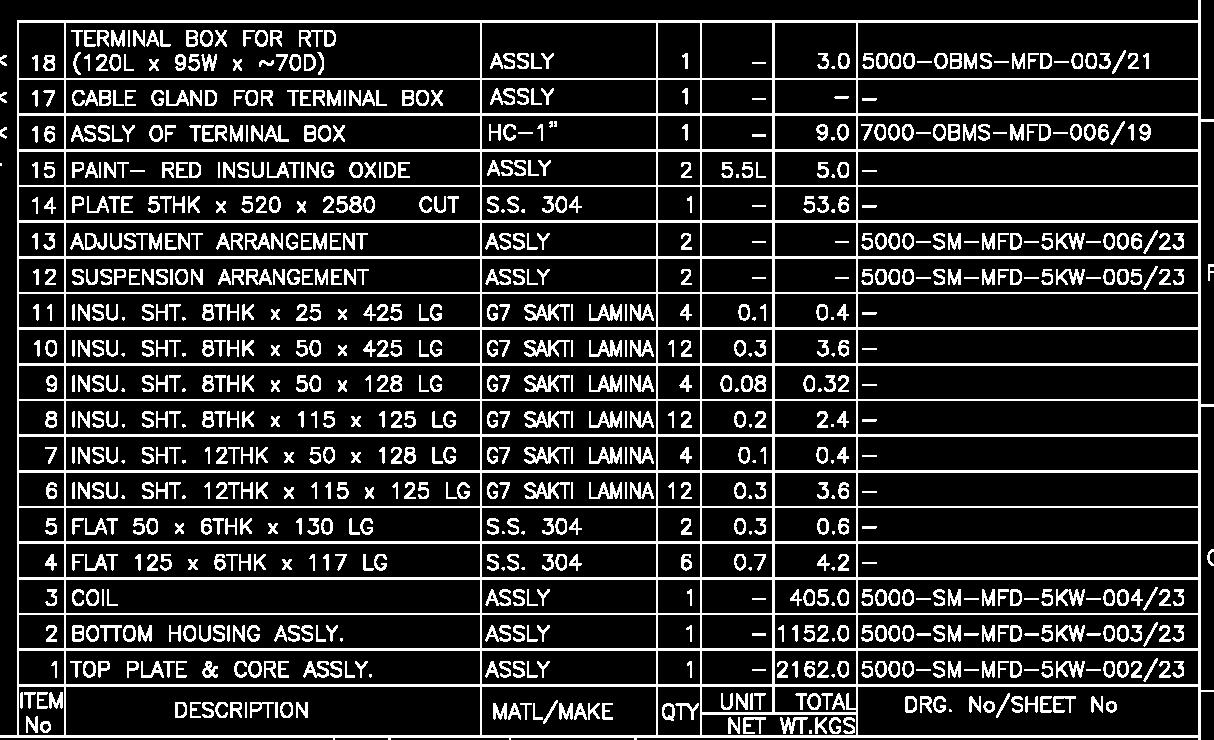

No. of columns =  7
width_frequency =  [1 1 1 1 1 1 1]
width list =  [340.  81.  70.  42. 174. 414.  45.]
Row count =  18


TypeError: Unsupported image object

In [10]:
# my_list = [602,603,604,605,606,607,608,609, 610]

all_bom_list = []
# for i in my_list:
    
individual_bom, serialised_header_text = bom_df_rev(pred_bom_id)
    
all_bom_list.append(individual_bom)
    
all_bom_array = np.vstack((all_bom_list))
all_bom_df = pd.DataFrame(all_bom_array, columns = serialised_header_text)

# making all descriptions in lower case :
all_bom_df['DESCRIPTION'] = all_bom_df['DESCRIPTION'].map(lambda x: x if type(x)!=str else x.lower())

for i in range(len(all_bom_df)):

    all_bom_df.iloc[i, 2] = all_bom_df.iloc[i, 2].replace('1/d', 'i/d')
    all_bom_df.iloc[i, 2] = all_bom_df.iloc[i, 2].replace('0/d', 'o/d')


In [9]:
def bom_df_rev(pred_bom_id):
    # Extract header and item details
    col_count_list, item_index_width_list, header_boxes_list, bom_boxes_list = header_and_item(pred_bom_id)
    
    # Read input image
    pred_bom = cv2.imread(pred_bom_id)
    
    # Ensure we have header boxes
    if not header_boxes_list or len(header_boxes_list) == 0:
        print("Error: No header boxes found!")
        return None, None

    # Extract header column widths
    width_list = header_boxes_list[0][:, 2]  
    x_list = header_boxes_list[0][:, 0]

    # Find the frequency of column widths
    width_frequency = np.unique(width_list, return_counts=True)[1]  
    print('Width Frequency:', width_frequency)

    # Get all column widths from BOM items
    all_width_list = bom_boxes_list[0][:, 2].tolist()
    row_count_array = np.bincount(all_width_list)  
    row_count_apparent = row_count_array.max()
    
    # Estimate row count
    row_count = row_count_apparent // np.max(width_frequency)
    print('Estimated Row Count:', row_count)

    # Extract header text
    header_text = []
    for box in header_boxes_list[0]:  
        x, y, w, h = map(int, box)  # Convert to integers
        header_crop = pred_bom[y:y+h, x:x+w]

        # Convert to grayscale & threshold
        header_gray = cv2.cvtColor(header_crop, cv2.COLOR_BGR2GRAY)
        _, header_bin = cv2.threshold(header_gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

        # OCR text extraction
        text = pytesseract.image_to_string(header_bin, config='--psm 6 --oem 3').strip()
        header_text.append(text)

    header_text.append('img_id')  
    serialised_header_text = header_text[::-1]  # Reverse order

    # Extract BOM items
    bom_text = []
    for i, bom_boxes in enumerate(bom_boxes_list):
        y_unique = np.unique(bom_boxes[:, 1])[::-1]  # Reverse order

        for j in y_unique:
            bom_sub_text = []
            aa = np.ones((col_count_list[0], 4))  

            bb = bom_boxes[bom_boxes[:, 1] == j]  # Select only rows with matching Y

            for k in range(len(width_list)):
                for l in range(len(bb)):
                    if (bb[l][2] + bb[l][0]) == (width_list[k] + x_list[k]):
                        aa[k, :] = bb[l, :]

            for k in range(len(aa)):
                x, y, w, h = map(int, aa[k])  
                cell_crop = pred_bom[y:y+h, x:x+w]  

                # Convert to grayscale & threshold
                cell_gray = cv2.cvtColor(cell_crop, cv2.COLOR_BGR2GRAY)
            
                _, cell_bin = cv2.threshold(cell_gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

                # OCR text extraction
                text = pytesseract.image_to_string(cell_bin, config='--psm 6 --oem 3').strip()
                #text = pytesseract.image_to_string(cell_bin, config='--psm 6 --oem 1 -c tessedit_char_whitelist=0123456789').strip()
                bom_sub_text.append(text)

            bom_id = ((pred_bom_id.split('/'))[-1].split('.'))[0] # making bom df with only drg no. and not with drg. path
            bom_sub_text.append(bom_id)  # Append image ID
            bom_text.append(bom_sub_text[::-1])  # Reverse order

    # Convert to DataFrame
    df = pd.DataFrame(bom_text, columns=serialised_header_text)
    return df, bom_text, bom_sub_text


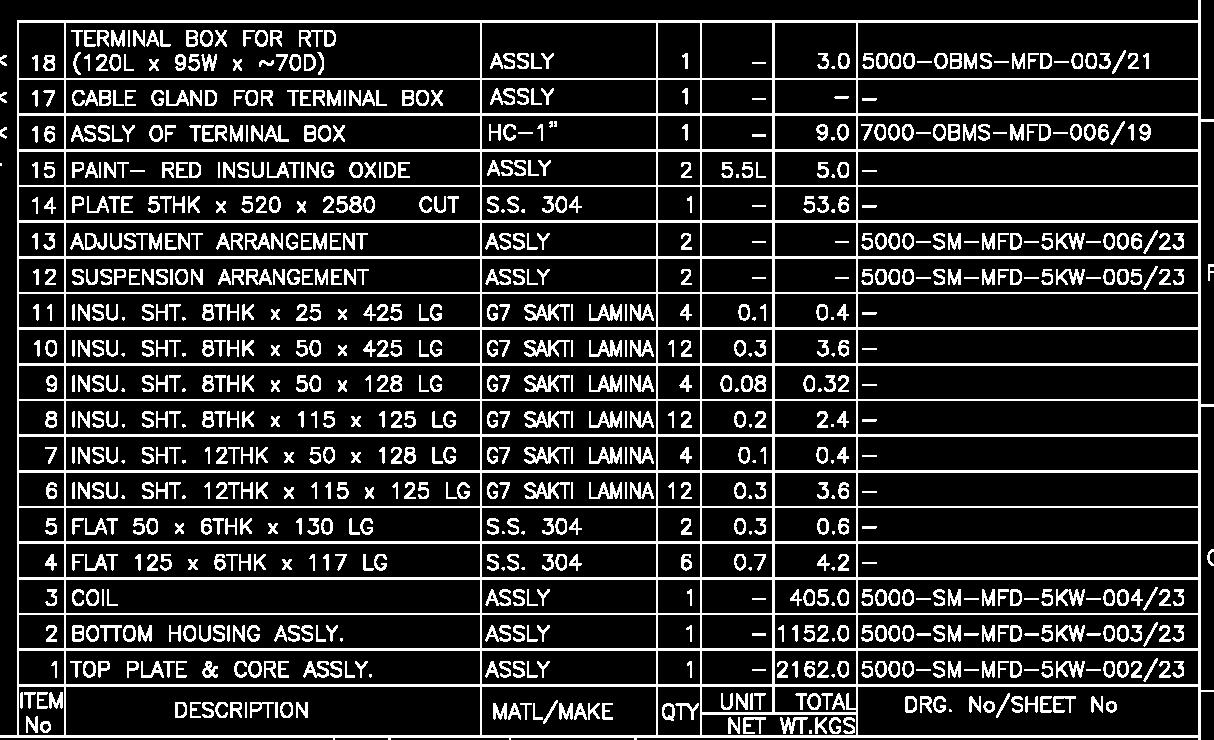

No. of columns =  7
Width Frequency: [1 1 1 1 1 1 1]
Estimated Row Count: 18


In [25]:
df, bom_text, bom_sub_text = bom_df_rev(pred_bom_id)

In [13]:
df.head(20)

,img_id,TEM\nNo,DESCRIPTION,MATL/MAKE,ary,UNIT,TOTAL,DRG. No/SHEET No
0,SM-MFD-5KW-001-23,4,TOP PLATE & CORE ASSLY.,ASSLY,4,ad,2162.0,5000—SM—MFD—5SKW-—002/23
1,SM-MFD-5KW-001-23,2,BOTTOM HOUSING ASSLY.,ASSLY,4,=,1152.0,5000-—SM—MFD—5SKW-003/23
2,SM-MFD-5KW-001-23,3,coIL,ASSLY,al,ad,405.0,5000—SM—MFD—5KW-004/23
3,SM-MFD-5KW-001-23,4,FLAT 125 x 8THK x 117 LG,$.S. 304,6,07,42,Se
4,SM-MFD-5KW-001-23,5,FLAT 50 x 6THK x 130 LG,S.S. 304,2,0.3),0.8),SH
5,SM-MFD-5KW-001-23,6,INSU. SHT. 12THK x 115 x 125 LG,G7 SAKTI LAMINA|,12),0.3),3.6,Se
6,SM-MFD-5KW-001-23,7,INSU. SHT. 12THK x 50 x 128 LG,G7 SAKTI LAMINA,4,0.1,0.4,Se
7,SM-MFD-5KW-001-23,8B,INSU. SHT. 8THK x 115 x 125 LG,G7 SAKTI LAMINA,12),0.2),24,SH
8,SM-MFD-5KW-001-23,7),INSU. SHT. 8THK x 50 x 128 LG,G7 SAKTI LAMINA|,4,0.08,0.32,Se
9,SM-MFD-5KW-001-23,10),INSU. SHT. 8THK x 50 x 425 LG,G7 SAKTI. LAMINA,12),0.3),3.8,Se


In [23]:
print(bom_text)
print(len(bom_text))

[['SM-MFD-5KW-001-23', '4', 'TOP PLATE & CORE ASSLY.', 'ASSLY', '4', 'ad', '2162.0', '5000—SM—MFD—5SKW-—002/23'], ['SM-MFD-5KW-001-23', '2', 'BOTTOM HOUSING ASSLY.', 'ASSLY', '4', '=', '1152.0', '5000-—SM—MFD—5SKW-003/23'], ['SM-MFD-5KW-001-23', '3', 'coIL', 'ASSLY', 'al', 'ad', '405.0', '5000—SM—MFD—5KW-004/23'], ['SM-MFD-5KW-001-23', '4', 'FLAT 125 x 8THK x 117 LG', '$.S. 304', '6', '07', '42', 'Se'], ['SM-MFD-5KW-001-23', '5', 'FLAT 50 x 6THK x 130 LG', 'S.S. 304', '2', '0.3)', '0.8)', 'SH'], ['SM-MFD-5KW-001-23', '6', 'INSU. SHT. 12THK x 115 x 125 LG', 'G7 SAKTI LAMINA|', '12)', '0.3)', '3.6', 'Se'], ['SM-MFD-5KW-001-23', '7', 'INSU. SHT. 12THK x 50 x 128 LG', 'G7 SAKTI LAMINA', '4', '0.1', '0.4', 'Se'], ['SM-MFD-5KW-001-23', '8B', 'INSU. SHT. 8THK x 115 x 125 LG', 'G7 SAKTI LAMINA', '12)', '0.2)', '24', 'SH'], ['SM-MFD-5KW-001-23', '7)', 'INSU. SHT. 8THK x 50 x 128 LG', 'G7 SAKTI LAMINA|', '4', '0.08', '0.32', 'Se'], ['SM-MFD-5KW-001-23', '10)', 'INSU. SHT. 8THK x 50 x 425 LG', 'G

In [26]:
print(bom_sub_text)
print(len(bom_sub_text))

['5000—OBMS—MFD—003/21', '30', 'a', '4', 'ASSLY', 'TERMINAL BOX FOR RTD\n(120L x 95W x ~70D)', '18', 'SM-MFD-5KW-001-23']
8


(740, 1214, 3)


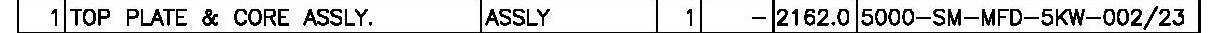

In [150]:
s = cv2.imread(pred_bom_id)
print(s.shape)
s_c= s[652:652+33, :, :]
#s_c= s[652:652+33, 20:20+45, :]
x_pil = Image.fromarray(s_c)
display(x_pil)

In [151]:
s_c_gray = cv2.cvtColor(s_c, cv2.COLOR_BGR2GRAY)
            
_, s_c_bin = cv2.threshold(s_c_gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

                # OCR text extraction
text = pytesseract.image_to_string(s_c_bin, config='--psm 6 --oem 3').strip()

print(text)

1|TOP PLATE & CORE ASSLY. ASSLY 1 —|2162.0 |5000—SM—MFD—5KW-—002/23


orininal image shape =  (740, 1214)
cropped image shape =  (740, 1183, 3)
leftmost_x =  17
rightmost_x =  1200
left margin =  inf
right margin =  3


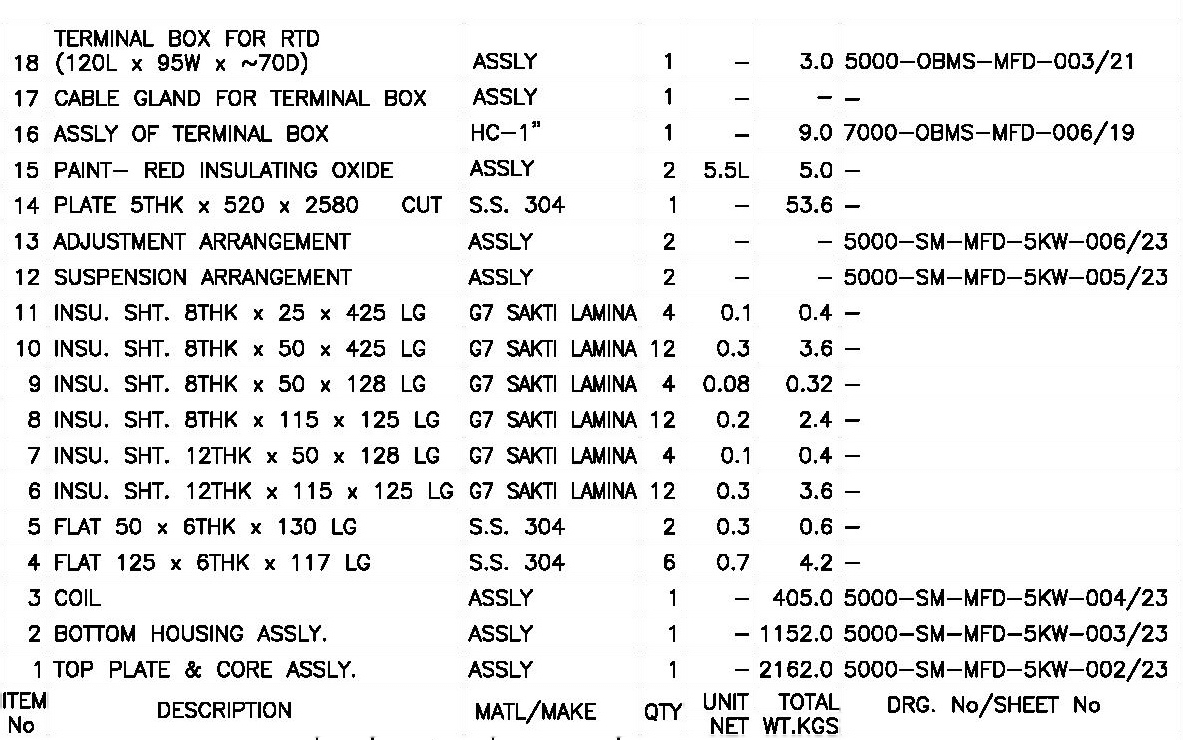

In [37]:
# remove_grid_lines(image_path, output_path):
def remove_grid_lines(image_path):
        
    # Read the image
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    print('orininal image shape = ', gray.shape)

    # Remove all characters beyond the extreme left and right longest grid lines:
    # Use edge detection to find vertical lines
    edges = cv2.Canny(gray, 50, 150, apertureSize=3)

    # Detect lines using Hough Transform
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 100, minLineLength=100, maxLineGap=10)
"""
    # Find the extreme left and right longest vertical lines
    leftmost_x, rightmost_x = float('inf'), float('-inf')

    for line in lines:
        x1, y1, x2, y2 = line[0]
        if abs(x1 - x2) < 10:  # Check if the line is vertical
            if x1 < leftmost_x:
                left_margin = leftmost_x - x1
                leftmost_x = x1
                
            if x1 > rightmost_x:
                right_margin = x1 - rightmost_x
                rightmost_x = x1
"""

    # Initialize extreme left and right x-coordinates
    leftmost_x = image.shape[1]  # Initialize with max width
    rightmost_x = 0  # Initialize with min width

    if lines is not None:  # Ensure lines are detected
        for line in lines:
            x1, y1, x2, y2 = line[0]
            if abs(x1 - x2) < 10:  # Check if the line is vertical
                leftmost_x = min(leftmost_x, x1)
                rightmost_x = max(rightmost_x, x1)

    # Ensure valid margins
    left_margin = leftmost_x if leftmost_x != image.shape[1] else 0
    right_margin = image.shape[1] - rightmost_x if rightmost_x != 0 else 0


    # Crop the image within detected leftmost and rightmost boundaries
    cropped_image = image[:, leftmost_x:rightmost_x]
    print('cropped image shape = ', cropped_image.shape)
    print('leftmost_x = ', leftmost_x)
    print('rightmost_x = ', rightmost_x)
    print('left margin = ', left_margin)
    print('right margin = ', right_margin)
    #===============================================================
    # Now remove all gridlines:
    # Apply adaptive threshold to detect lines

    cropped_image_gray = cv2.cvtColor(cropped_image, cv2.COLOR_BGR2GRAY)
    thresh = cv2.adaptiveThreshold(cropped_image_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 15, 2)
    
    # Define horizontal and vertical kernels for morphological operations
    horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1))
    vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 40))
    
    # Detect horizontal and vertical lines
    horizontal_lines = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, horizontal_kernel, iterations=2)
    vertical_lines = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, vertical_kernel, iterations=2)
    
    # Combine the detected lines
    grid_lines = cv2.add(horizontal_lines, vertical_lines)
    
    # Inpaint the grid lines to remove them
    inpainted_image = cv2.inpaint(cropped_image, grid_lines, inpaintRadius=3, flags=cv2.INPAINT_TELEA)

    return inpainted_image
    
    """
    # Save the output image
    cv2.imwrite(output_path, inpainted_image)
    
    print(f"Processed image saved as {output_path}")
    """
# Example usage
    
pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom/SM-MFD-5KW-001-23.jpg"
output = remove_grid_lines(pred_bom_id)
x_pil = Image.fromarray(output)
display(x_pil)


Original image shape = (740, 1214)
Cropped image shape = (740, 1183, 3)
leftmost_x = 17
rightmost_x = 1200
Left margin = 17
Right margin = 14


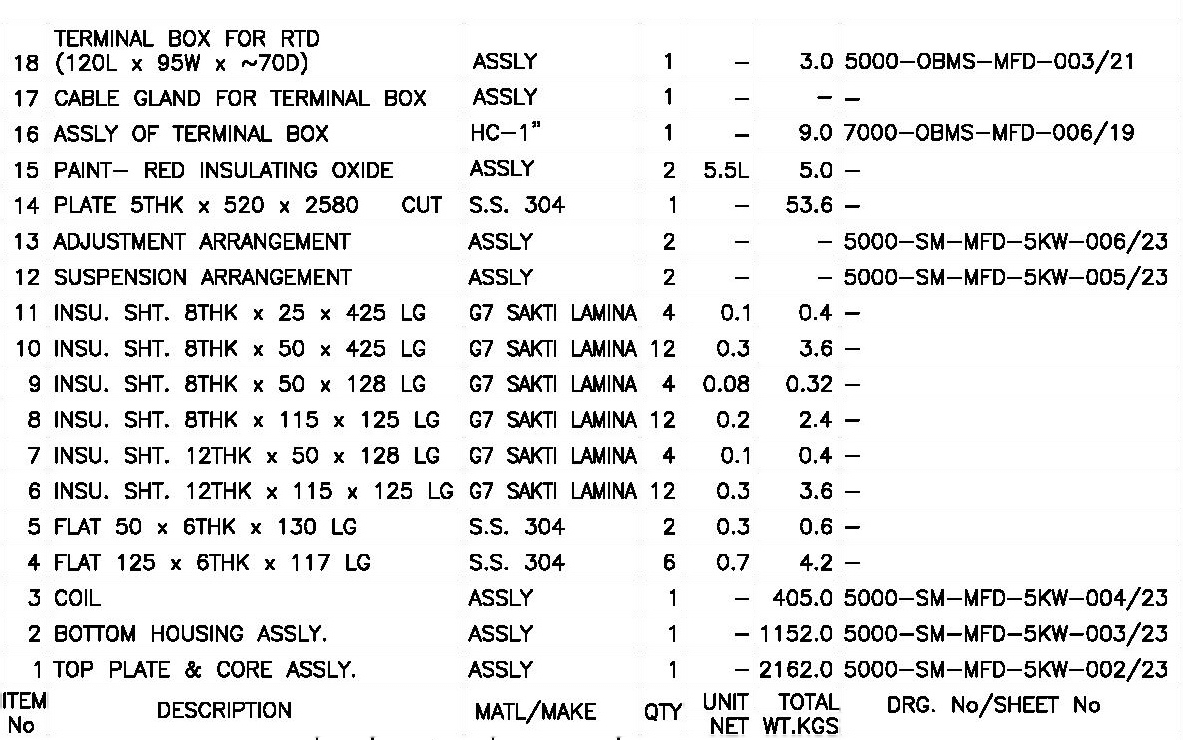

In [12]:
def remove_grid_lines(image_path):    
    # Read the image
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    print('Original image shape =', gray.shape)

    # Edge detection to find vertical lines
    edges = cv2.Canny(gray, 50, 150, apertureSize=3)

    # Detect lines using Hough Transform
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 100, minLineLength=100, maxLineGap=10)

    # Initialize extreme left and right x-coordinates
    leftmost_x = image.shape[1]  # Initialize with max width
    rightmost_x = 0  # Initialize with min width

    if lines is not None:  # Ensure lines are detected
        for line in lines:
            x1, y1, x2, y2 = line[0]
            if abs(x1 - x2) < 10:  # Check if the line is vertical
                leftmost_x = min(leftmost_x, x1)
                rightmost_x = max(rightmost_x, x1)

    # Ensure valid margins
    left_margin = leftmost_x if leftmost_x != image.shape[1] else 0
    right_margin = image.shape[1] - rightmost_x if rightmost_x != 0 else 0

    # Crop the image within detected leftmost and rightmost boundaries
    cropped_image = image[:, leftmost_x:rightmost_x]
    print('Cropped image shape =', cropped_image.shape)
    print('leftmost_x =', leftmost_x)
    print('rightmost_x =', rightmost_x)
    print('Left margin =', left_margin)
    print('Right margin =', right_margin)

    #===============================================================
    # Now remove all gridlines:
    cropped_image_gray = cv2.cvtColor(cropped_image, cv2.COLOR_BGR2GRAY)
    thresh = cv2.adaptiveThreshold(cropped_image_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 15, 2)
    
    # Define horizontal and vertical kernels for morphological operations
    horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1))
    vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 40))
    
    # Detect horizontal and vertical lines
    horizontal_lines = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, horizontal_kernel, iterations=2)
    vertical_lines = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, vertical_kernel, iterations=2)
    
    # Combine the detected lines
    grid_lines = cv2.add(horizontal_lines, vertical_lines)
    
    # Inpaint the grid lines to remove them
    inpainted_image = cv2.inpaint(cropped_image, grid_lines, inpaintRadius=3, flags=cv2.INPAINT_TELEA)

    return inpainted_image

# Example usage
pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom/SM-MFD-5KW-001-23.jpg"
output = remove_grid_lines(pred_bom_id)
x_pil = Image.fromarray(output)
display(x_pil)


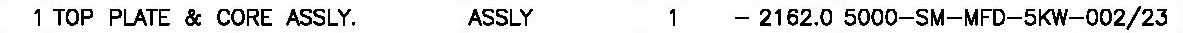

In [27]:
y = 652
h = 33
s_c= output[y:y+h, :, :]
#s_c= s[652:652+33, 20:20+45, :]
x_pil = Image.fromarray(s_c)
display(x_pil)

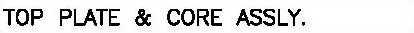

In [49]:
y = 652
h = 33
x = 67
w = 414
s_c= output[y:y+h, x-17:x+w-17, :]
#s_c= s[652:652+33, 20:20+45, :]
x_pil = Image.fromarray(s_c)
display(x_pil)

In [46]:
s_c_gray = cv2.cvtColor(s_c, cv2.COLOR_BGR2GRAY)
            
_, s_c_bin = cv2.threshold(s_c_gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

                # OCR text extraction
text = pytesseract.image_to_string(s_c_bin, config='--psm 6 --oem 3').strip()

print(text)

In [17]:
print(type(text))

<class 'str'>


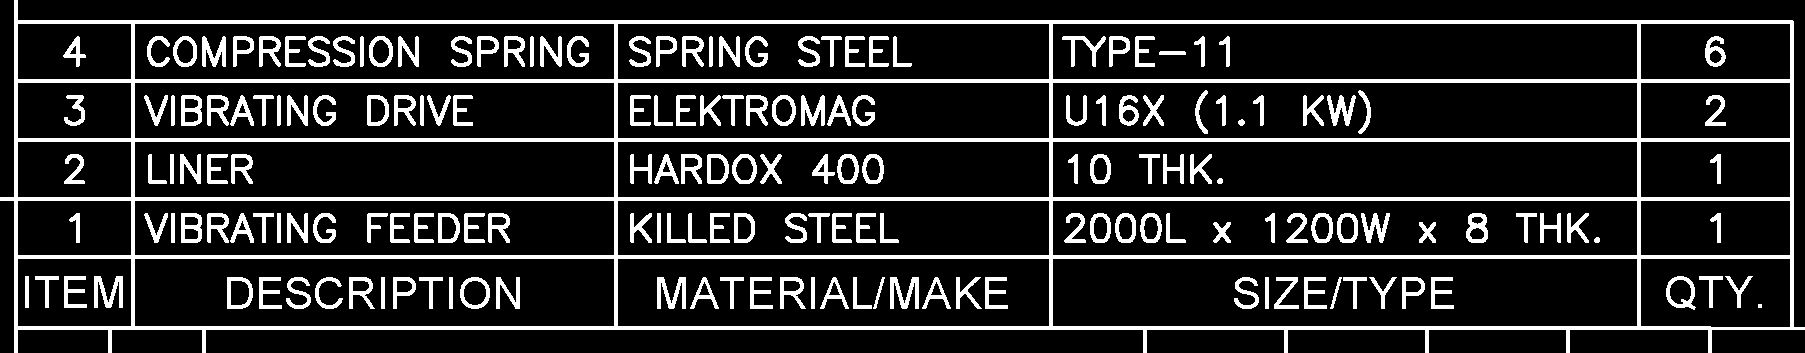

No. of columns =  5


In [54]:
pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom/1023.jpg"
col_count_list, item_index_width_list , header_boxes_list, bom_boxes_list =  header_and_item(pred_bom_id) ## all boxes in x, y, w, h format


Original image shape = (353, 1805)
Cropped image shape = (353, 1780, 3)
leftmost_x = 13
rightmost_x = 1793
Left margin = 13
Right margin = 12


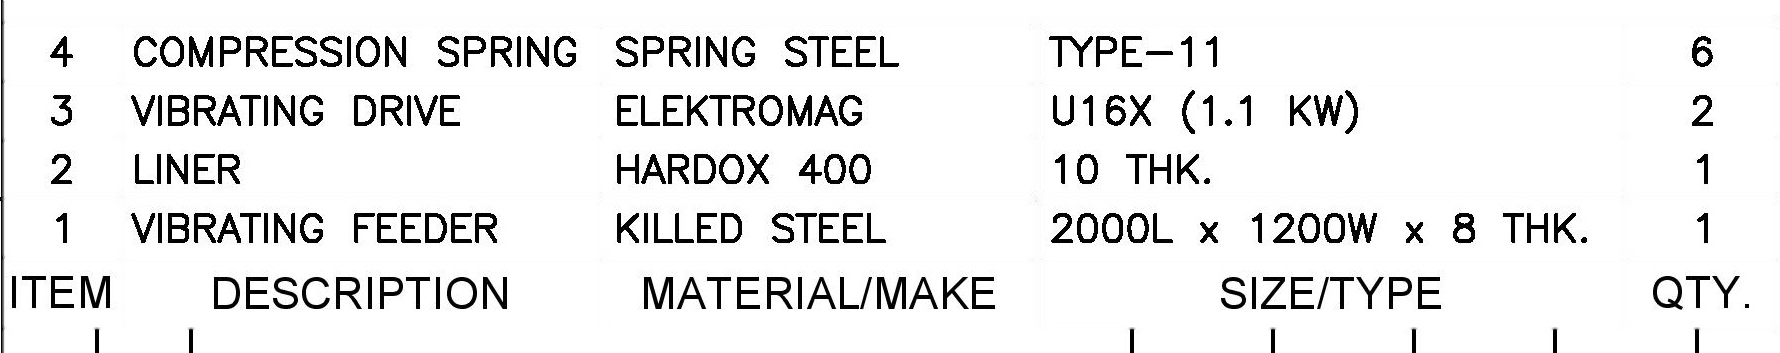

In [55]:
output = remove_grid_lines(pred_bom_id)
x_pil = Image.fromarray(output)
display(x_pil)

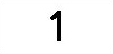

In [56]:
y = 202
h = 54
x = 19
w = 113
#m = int(left_margin)
s_c_1= output[y:y+h, x-13:x+w-13, :]
#s_c= s[652:652+33, 20:20+45, :]
x_pil = Image.fromarray(s_c_1)
display(x_pil)

In [90]:
s_c_1_gray = cv2.cvtColor(s_c_1, cv2.COLOR_BGR2GRAY)
            
_, s_c_bin = cv2.threshold(s_c_1_gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

                # OCR text extraction
text = pytesseract.image_to_string(s_c_bin, config='--psm 6 --oem 3').strip()
print(text)

4


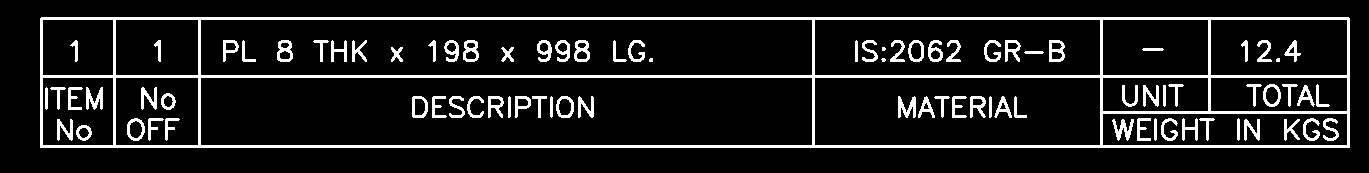

No. of columns =  6


In [58]:
pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom/1039.jpg"
col_count_list, item_index_width_list , header_boxes_list, bom_boxes_list =  header_and_item(pred_bom_id) ## all boxes in x, y, w, h format


Original image shape = (173, 1369)
Cropped image shape = (173, 1311, 3)
leftmost_x = 39
rightmost_x = 1350
Left margin = 39
Right margin = 19


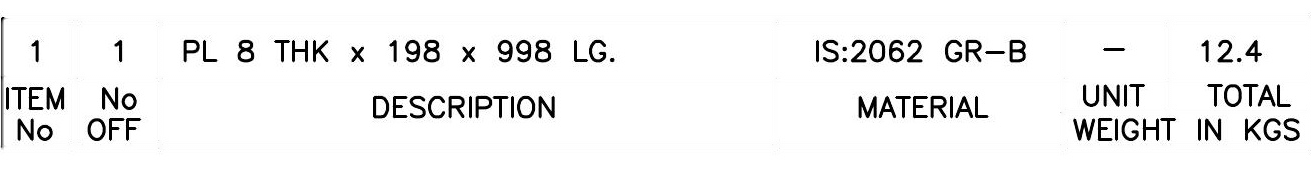

In [59]:
output = remove_grid_lines(pred_bom_id)
x_pil = Image.fromarray(output)
display(x_pil)

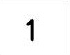

In [60]:
y = 21
h = 55
x = 44
w = 70
#m = int(left_margin)
s_c_2= output[y:y+h, x-39:x+w-39, :]
#s_c= s[652:652+33, 20:20+45, :]
x_pil = Image.fromarray(s_c_2)
display(x_pil)

In [61]:
s_c_2_gray = cv2.cvtColor(s_c_2, cv2.COLOR_BGR2GRAY)

_, s_c_bin = cv2.threshold(s_c_2_gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

                # OCR text extraction
text = pytesseract.image_to_string(s_c_bin, config='--psm 6 --oem 3').strip()
print(text)

1


In [102]:
print(s_c_1.shape)
print(s_c_2.shape)

(54, 113, 3)
(55, 70, 3)


In [104]:
s_c_1_resized = cv2.resize(s_c_1, (25, 25), interpolation=cv2.INTER_LANCZOS4)
s_c_2_resized = cv2.resize(s_c_2, (25, 25), interpolation=cv2.INTER_LANCZOS4)



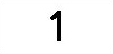

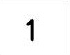

In [105]:

x_pil = Image.fromarray(s_c_1)
display(x_pil)
print('=============================')
x_pil = Image.fromarray(s_c_1_resized)
display(x_pil)
print('=============================')

x_pil = Image.fromarray(s_c_2)
display(x_pil)
print('=============================')
x_pil = Image.fromarray(s_c_2_resized)
display(x_pil)

In [106]:
print(s_c_1.shape)
print(s_c_1_resized.shape)
print(s_c_2.shape)
print(s_c_2_resized.shape)


(54, 113, 3)
(25, 25, 3)
(55, 70, 3)
(25, 25, 3)


In [107]:
s_c_1_gray = cv2.cvtColor(s_c_1, cv2.COLOR_BGR2GRAY)
_, s_c_bin = cv2.threshold(s_c_1_gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
text = pytesseract.image_to_string(s_c_bin, config='--psm 6 --oem 3').strip()
print('s_c_1 = ', text)

print('========================================')

s_c_1_resized_gray = cv2.cvtColor(s_c_1_resized, cv2.COLOR_BGR2GRAY)
_, s_c_bin = cv2.threshold(s_c_1_resized_gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
text = pytesseract.image_to_string(s_c_bin, config='--psm 6 --oem 3').strip()
print('s_c_1_resized = ', text)

print('========================================')

s_c_2_gray = cv2.cvtColor(s_c_2, cv2.COLOR_BGR2GRAY)
_, s_c_bin = cv2.threshold(s_c_2_gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
text = pytesseract.image_to_string(s_c_bin, config='--psm 6 --oem 3').strip()
print('s_c_2 = ', text)

print('========================================')

s_c_2_resized_gray = cv2.cvtColor(s_c_2_resized, cv2.COLOR_BGR2GRAY)
_, s_c_bin = cv2.threshold(s_c_2_resized_gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
text = pytesseract.image_to_string(s_c_bin, config='--psm 6 --oem 3').strip()
print('s_c_1_resized = ', text)

s_c_1 =  4
s_c_1_resized =  1
s_c_2 =  1
s_c_1_resized =  1


In [76]:
print(s_c_1_gray.shape)
print(s_c_1_resized_gray.shape)
print(s_c_2_gray.shape)

(54, 113)
(55, 70)
(55, 70)


In [77]:
print(s_c_1_gray)

[[255 255 255 ... 255 253 254]
 [255 252 253 ... 250 252 254]
 [255 251 255 ... 255 252 255]
 ...
 [253 255 254 ... 252 255 254]
 [255 251 255 ... 252 255 255]
 [251 254 255 ... 255 255 254]]


Original image shape = (231, 712)
Cropped image shape = (231, 698, 3)
leftmost_x = 12
rightmost_x = 710
Left margin = 12
Right margin = 2


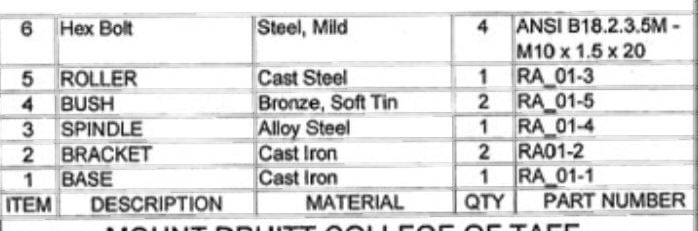

In [108]:
pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom/Screenshot_1_2025.jpg"
output = remove_grid_lines(pred_bom_id)
x_pil = Image.fromarray(output)
display(x_pil)

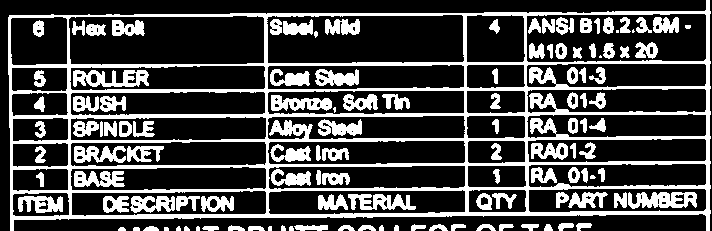

[array([[294., 226.,  36.,   5.],
       [  8.,   0., 704., 231.],
       [ 14., 194.,  56.,  23.],
       [ 18., 197.,  37.,   5.],
       [ 73., 192., 194.,  24.],
       [131., 208.,  26.,   3.],
       [131., 199.,  26.,   3.],
       [176., 198.,  26.,   3.],
       [470., 191.,  57.,  22.],
       [270., 191., 196.,  24.],
       [318., 205.,  31.,   3.],
       [348., 195.,  26.,   5.],
       [530., 190., 177.,  23.],
       [570., 202.,  25.,   3.],
       [637., 198.,  53.,  10.],
       [582., 194.,  28.,   4.],
       [671., 193.,  27.,   3.],
       [ 14., 170.,  55.,  22.],
       [ 72., 168., 195.,  23.],
       [100., 183.,  26.,   3.],
       [469., 167.,  58.,  21.],
       [270., 167., 196.,  23.],
       [281., 176.,  32.,  10.],
       [322., 175.,  29.,   4.],
       [530., 165., 177.,  23.],
       [ 14., 144.,  55.,  24.],
       [ 72., 143., 195.,  24.],
       [ 74., 155.,  25.,   3.],
       [134., 146.,  32.,   5.],
       [469., 142.,  57.,  22.],
       [2

In [109]:
bom_boxes = all_boxes(pred_bom_id)
print(bom_boxes)

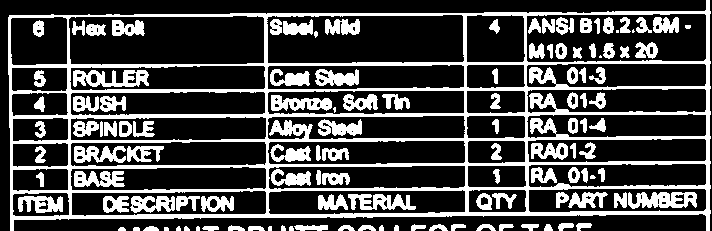

No. of columns =  2
[2]
[37.0]
[array([[ 14., 194.,  56.,  23.],
       [582., 194.,  28.,   4.]])]
[array([[ 18., 197.,  37.,   5.],
       [ 73., 192., 194.,  24.],
       [131., 208.,  26.,   3.],
       [131., 199.,  26.,   3.],
       [176., 198.,  26.,   3.],
       [470., 191.,  57.,  22.],
       [270., 191., 196.,  24.],
       [318., 205.,  31.,   3.],
       [348., 195.,  26.,   5.],
       [530., 190., 177.,  23.],
       [570., 202.,  25.,   3.],
       [637., 198.,  53.,  10.],
       [671., 193.,  27.,   3.],
       [ 14., 170.,  55.,  22.],
       [ 72., 168., 195.,  23.],
       [100., 183.,  26.,   3.],
       [469., 167.,  58.,  21.],
       [270., 167., 196.,  23.],
       [281., 176.,  32.,  10.],
       [322., 175.,  29.,   4.],
       [530., 165., 177.,  23.],
       [ 14., 144.,  55.,  24.],
       [ 72., 143., 195.,  24.],
       [ 74., 155.,  25.,   3.],
       [134., 146.,  32.,   5.],
       [469., 142.,  57.,  22.],
       [269., 142., 197.,  23.],
       [

In [110]:
col_count_list, item_index_width_list , header_boxes_list, bom_boxes_list =  header_and_item(pred_bom_id) ## all boxes in x, y, w, h format

print(col_count_list)
print('============================================')
print(item_index_width_list)
print('============================================')
print(header_boxes_list)
print('============================================')
print(bom_boxes_list)